In [15]:
from pathlib import Path
import json
import yaml
import pandas as pd
import matplotlib.pyplot as plt

## Configuration

Set `RESULTS_ROOT` to a directory that *contains* the run folders: it is searched
recursively for every `run_data.json` (Hydra nests runs as `runs_<problem>/<date>/<time>/`).

Alternatively, list explicit run folders in `RUN_FOLDERS` (this takes precedence).

In [16]:
# Directory searched recursively for runs (each run = folder with .hydra/ and run_data.json).
RESULTS_ROOT = Path("/home/riccardorota/PACS/PACSproject/results/runs_toy/2026-06-11")

# Optional: explicit list of run folders. If non-empty, RESULTS_ROOT is ignored.
RUN_FOLDERS = []

# Name of the test metric to report (as stored in run_data.json["test_metrics"]).
METRIC = "RRMSE"

## Helpers

In [17]:
def find_run_folders(root, explicit):
    """Return the run folders to parse: the explicit list if given, otherwise every
    folder under `root` that holds both run_data.json and .hydra/config.yaml."""
    if explicit:
        return [Path(p) for p in explicit]
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"RESULTS_ROOT does not exist: {root.resolve()}")
    folders = {
        p.parent
        for p in root.rglob("run_data.json")
        if (p.parent / ".hydra" / "config.yaml").exists()
    }
    return sorted(folders)


def _load_yaml(path):
    with open(path) as f:
        return yaml.safe_load(f)


def _class_name(target):
    """'models.Siren' -> 'Siren'."""
    return str(target).split(".")[-1] if target else None


def _blocks_by_role(model_cfg, role_suffix):
    """All block dicts in the model config whose _target_ ends with role_suffix
    (e.g. 'TargetNetwork', 'Hypernetwork')."""
    return [
        v for v in model_cfg.values()
        if isinstance(v, dict) and str(v.get("_target_", "")).endswith(role_suffix)
    ]


def _num_layers(network):
    """A network whose num_neurons list has length L has L-1 linear layers.
    Only the length of the list is needed, so unresolved ${...} entries are fine."""
    n = (network or {}).get("num_neurons")
    return (len(n) - 1) if isinstance(n, list) else None

In [18]:
def parse_run(folder):
    """Read one run folder and return a dict of summary fields."""
    folder = Path(folder)
    cfg = _load_yaml(folder / ".hydra" / "config.yaml")
    with open(folder / "run_data.json") as f:
        run = json.load(f)

    model = cfg.get("model", {}) or {}
    target_blocks = _blocks_by_role(model, "TargetNetwork")
    hyper_blocks = _blocks_by_role(model, "Hypernetwork")

    # Target network type (Siren vs MLP); if split across blocks they share the type.
    target_types = {
        _class_name((b.get("network") or {}).get("_target_")) for b in target_blocks
    }
    target_types.discard(None)
    target_type = "/".join(sorted(target_types)) or None

    # Hypernetwork type (always MLP, but derived for safety).
    hyper_types = {
        _class_name((b.get("network") or {}).get("_target_")) for b in hyper_blocks
    }
    hyper_types.discard(None)
    hyper_type = "/".join(sorted(hyper_types)) or "MLP"

    # Layer counts. The full target network may be split over several blocks
    # (e.g. target_first_layer + target_other_layers), so sum their layers.
    per_target = [_num_layers(b.get("network")) for b in target_blocks]
    per_target = [x for x in per_target if x is not None]
    target_layers = sum(per_target) if per_target else None
    hyper_layers = _num_layers(hyper_blocks[0].get("network")) if hyper_blocks else None

    # Data settings (present for the toy problem; absent for turbulence).
    train = (cfg.get("data_source", {}) or {}).get("train", {}) or {}
    N = train.get("N")
    n_realizations = train.get("n_realizations")

    # Test metric.
    rrmse = (run.get("test_metrics", {}) or {}).get(METRIC)

    return {
        "run": folder.name,
        "target_type": target_type,
        "hyper_type": hyper_type,
        "N": N,
        "n_realizations": n_realizations,
        "hyper_layers": hyper_layers,
        "target_layers": target_layers,
        f"{METRIC}_test": rrmse,
        "path": str(folder),
    }

## Build the table

In [19]:
folders = find_run_folders(RESULTS_ROOT, RUN_FOLDERS)
print(f"Found {len(folders)} run folder(s).")

rows = []
for folder in folders:
    try:
        rows.append(parse_run(folder))
    except Exception as e:
        print(f"[skip] {folder}: {type(e).__name__}: {e}")

columns = [
    "run", "target_type", "hyper_type", "N", "n_realizations",
    "hyper_layers", "target_layers", f"{METRIC}_test", "path",
]
df = pd.DataFrame(rows, columns=columns)
df

Found 18 run folder(s).


,run,target_type,hyper_type,N,n_realizations,hyper_layers,target_layers,RRMSE_test,path
0,18-40-15,MLP,MLP,100,1,3,3,0.191979,/home/riccardorota/PACS/PACSproject/results/ru...
1,18-57-51,MLP,MLP,1000,1,3,3,0.054564,/home/riccardorota/PACS/PACSproject/results/ru...
2,19-15-58,MLP,MLP,10000,1,3,3,0.002646,/home/riccardorota/PACS/PACSproject/results/ru...
3,19-37-44,MLP,MLP,100,10,3,3,0.269814,/home/riccardorota/PACS/PACSproject/results/ru...
4,19-39-34,MLP,MLP,1000,10,3,3,0.096550,/home/riccardorota/PACS/PACSproject/results/ru...
5,19-41-52,MLP,MLP,10000,10,3,3,0.002613,/home/riccardorota/PACS/PACSproject/results/ru...
6,19-59-57,MLP,MLP,100,100,3,3,0.157392,/home/riccardorota/PACS/PACSproject/results/ru...
7,20-04-20,MLP,MLP,1000,100,3,3,0.343012,/home/riccardorota/PACS/PACSproject/results/ru...
8,20-06-15,MLP,MLP,10000,100,3,3,0.031048,/home/riccardorota/PACS/PACSproject/results/ru...
9,20-16-30,Siren,MLP,100,1,3,3,0.250925,/home/riccardorota/PACS/PACSproject/results/ru...


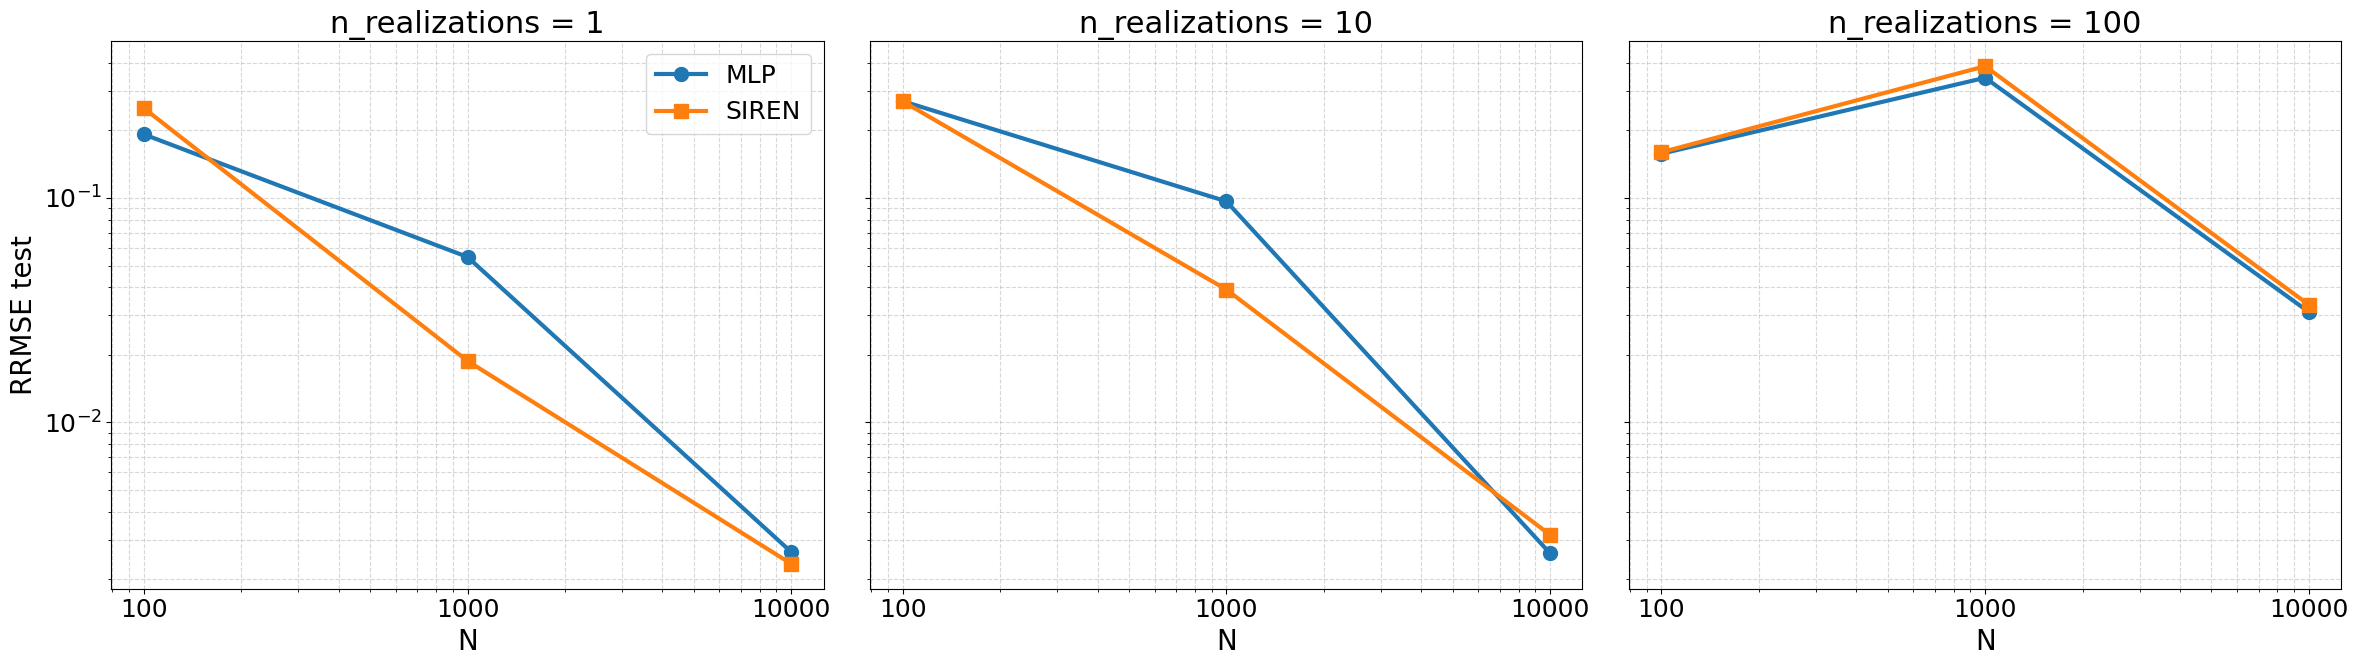

In [21]:
plt.rcParams.update({
    'font.size': 18, 
    'axes.labelsize': 20, 
    'axes.titlesize': 22, 
    'legend.fontsize': 18
})

# Dynamically extract the unique n_realizations from your dataframe and sort them
realizations = sorted(df['n_realizations'].unique())

# Create 1x3 subplot grid with a shared Y-axis (adjust columns based on unique realizations)
fig, axes = plt.subplots(1, len(realizations), figsize=(24, 7), sharey=True)

for ax, n_real in zip(axes, realizations):
    # Filter data for the current n_realizations value
    subset = df[df['n_realizations'] == n_real]
    
    # Extract and sort data for MLP and Siren to ensure lines plot correctly
    mlp_data = subset[subset['target_type'] == 'MLP'].sort_values('N')
    siren_data = subset[subset['target_type'] == 'Siren'].sort_values('N')
    
    # Plot lines with thicker widths and larger markers
    ax.loglog(mlp_data['N'], mlp_data['RRMSE_test'], marker='o', linewidth=3, markersize=10, label='MLP', color='#1f77b4')
    ax.loglog(siren_data['N'], siren_data['RRMSE_test'], marker='s', linewidth=3, markersize=10, label='SIREN', color='#ff7f0e')
    
    ax.set_title(f'n_realizations = {n_real}')
    ax.set_xlabel('N')
    
    # Apply log scale to evenly distribute N=100, 1000, 10000
    ax.set_xscale('log')
    ax.set_xticks([100, 1000, 10000])
    ax.get_xaxis().set_major_formatter(plt.ScalarFormatter()) # Prevents scientific notation (10^2)
    
    ax.grid(True, which="both", ls="--", alpha=0.5)
    
    # Only add the Y-label and legend to the first (left-most) plot to reduce clutter
    if n_real == realizations[0]:
        ax.set_ylabel('RRMSE test')
        ax.legend()

plt.tight_layout()

# Save the figure for your report
plt.savefig('RRMSE_comparison_plots.png', dpi=300, bbox_inches='tight')
plt.show()